# Exploratory Data Analysis

Even though our dataset was synthetically generated, it is still valuable to perform **exploratory data analysis** to indicate common steps that should be performed in context in which we don't have control of the data generating process and to analyze the differences between the data generated for each variant

## Importing and Inspecting

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the dataset
conversion_df = pd.read_csv("../data/ab_test_data.csv")

In [3]:
# Inspecting the dataset's structure
conversion_df.head()

,group,converted
0,A,0
1,A,1
2,A,0
3,A,0
4,A,0


In [4]:
# Analyzing dataset size
conversion_df.shape

(2000, 2)

In [5]:
# Verifying presence of missing values
conversion_df.isnull().sum()

group        0
converted    0
dtype: int64

In [6]:
# Validating column types
conversion_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   group      2000 non-null   str  
 1   converted  2000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 31.4 KB


By the above outputs, we can summarize our findings as follows:
- The dataset is composed of two columns: **group** and **converted** (of types **str** and **int64**, respectively)
- We have 2000 rows, none of each has missing values
- The column data types are coherent with the data they represent

## Distribution analysis

Now, analyses will be conducted with regards to the distribution of conversion and group observations

In [7]:
# Distribution of observations from each group
conversion_df["group"].value_counts(normalize=True)

group
A    0.5
B    0.5
Name: proportion, dtype: float64

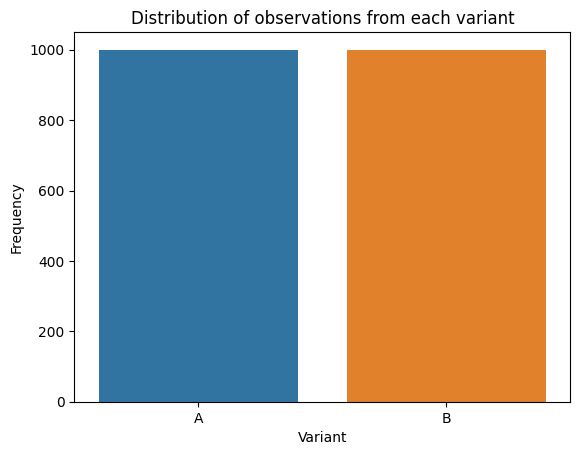

In [8]:
# Visualization of the distributions of observations from each group
ax = sns.countplot(data=conversion_df, x="group", hue="group")
ax.set_title("Distribution of observations from each variant")
ax.set_xlabel("Variant")
ax.set_ylabel("Frequency")
plt.show()

In [9]:
# Distribution of conversion x non-conversion values
conversion_df["converted"].value_counts(normalize=True)

converted
0    0.862
1    0.138
Name: proportion, dtype: float64

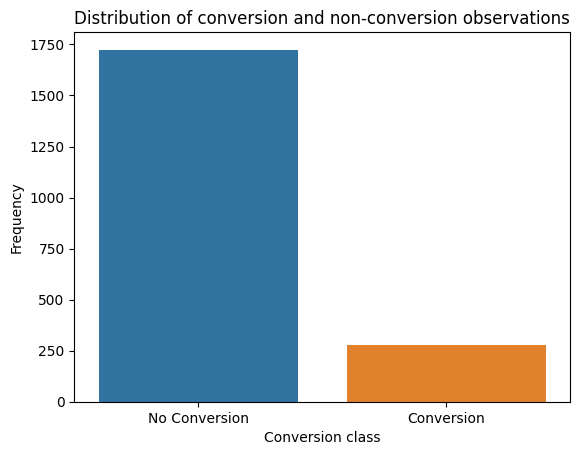

In [10]:
# Visualization of the distribution of conversion x non-conversion values
ax = sns.countplot(data=conversion_df.replace({"converted": {0: "No Conversion", 1: "Conversion"}}), x="converted", hue="converted")
ax.set_title("Distribution of conversion and non-conversion observations")
ax.set_xlabel("Conversion class")
ax.set_ylabel("Frequency")
plt.show()

From the above outputs, it's clear that the distribution of observations from each group is equal (as expected by the data generation process) and that the distribution of the conversion class is imbalanced with a lot more no-conversion observations (also expected given the data generation process)

## Conversion Rates

In this section, conversion rates for each variant will be calculated, compared and analyzed

In [11]:
# To facilitate our work, a contingency table will be created first
contingency_table = pd.crosstab(conversion_df["group"], conversion_df["converted"], margins=True)
contingency_table

converted,0,1,All
group,,,
A,876,124,1000
B,848,152,1000
All,1724,276,2000


In [12]:
# Calculating conversion rate for each variant
conversion_rates = conversion_df.groupby("group")["converted"].mean()
conversion_rates

group
A    0.124
B    0.152
Name: converted, dtype: float64

It's great to see that the observed conversion rate (0.124 for variant A and 0.152 for B) are a lot close to the theoretical probabilities from which we generated data (0.12 for variant A and 0.15 for B)

## Visualizing conversions

Now, plots will be presented to visualize the behavior of conversion in each group and between groups

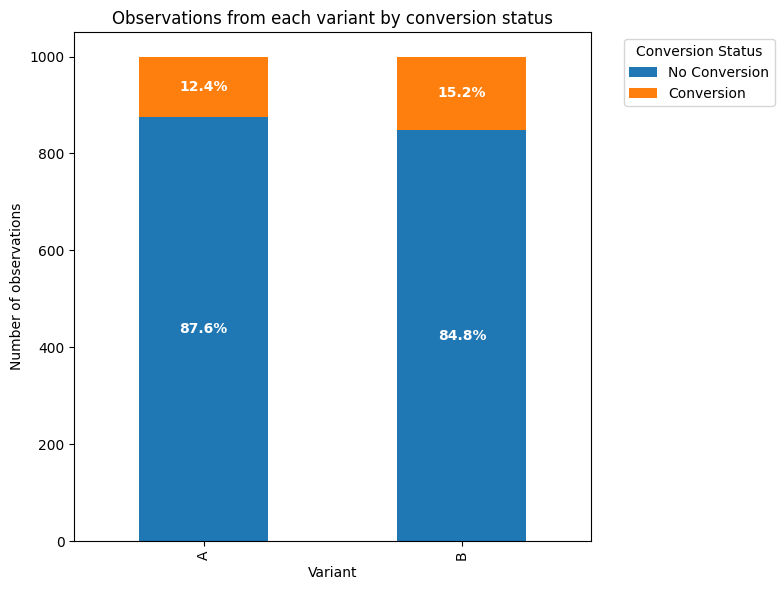

In [13]:
# Creating a stacked bar plot
contingency_plot_data = pd.crosstab(conversion_df['group'], conversion_df['converted'])

ax = contingency_plot_data.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#1f77b4', '#ff7f0e'])
ax.set_title('Observations from each variant by conversion status')
ax.set_xlabel('Variant')
ax.set_ylabel('Number of observations')

# Calculate the proportions for labels
proportions = contingency_plot_data.div(contingency_plot_data.sum(axis=1), axis=0)

# Add percentage labels to each bar segment
for i, container in enumerate(ax.containers):
    labels = [f"{prop * 100:.1f}%" for prop in proportions.iloc[:, i]]
    ax.bar_label(container, labels=labels, label_type='center', color='white', weight='bold')

plt.legend(title='Conversion Status', labels=['No Conversion', 'Conversion'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()